## Step 1 — Install Dependencies

In [23]:
!pip install -q "sentence-transformers>=3.3.0" accelerate huggingface_hub

## Step 2 — Imports

In [24]:
import json, time, random, math, os, glob, csv
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

import torch
from sentence_transformers import SentenceTransformer, InputExample, losses, evaluation, util
from torch.utils.data import DataLoader

print('sentence-transformers :', __import__('sentence_transformers').__version__)
print('PyTorch               :', torch.__version__)
print('CUDA available        :', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU                   :', torch.cuda.get_device_name(0))
    print('VRAM                  :', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), 'GB')

sentence-transformers : 5.4.0
PyTorch               : 2.10.0+cu128
CUDA available        : True
GPU                   : Tesla T4
VRAM                  : 15.6 GB


## Step 3 — Configuration
Set all hyperparameters and paths here before running the notebook.

In [25]:
BASE_MODEL   = 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2'
DATA_PATH    = '/kaggle/input/datasets/rahma123456y/recommedation/recommendation_training_dataset.jsonl'
OUTPUT_DIR   = '/kaggle/working/model3_recommendation'
CHARTS_DIR   = '/kaggle/working/charts'
HF_REPO      = 's-rahma/assistify-recommendation-model'

BATCH_SIZE   = 64
EPOCHS       = 3
WARMUP_RATIO = 0.1
MAX_SEQ_LEN  = 128
EVAL_SPLIT   = 0.05

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
Path(CHARTS_DIR).mkdir(parents=True, exist_ok=True)
print('Config ready.')

Config ready.


## Step 4 — Load Dataset
Load the JSONL file and split into train / eval sets (95% / 5%).

In [26]:
raw = []
with open(DATA_PATH, 'r', encoding='utf-8') as f:
    for line in f:
        raw.append(json.loads(line))

random.shuffle(raw)
split_idx  = int(len(raw) * (1 - EVAL_SPLIT))
train_data = raw[:split_idx]
eval_data  = raw[split_idx:]

print(f'Total  : {len(raw):,}')
print(f'Train  : {len(train_data):,}')
print(f'Eval   : {len(eval_data):,}')
print('\nSample:')
print(json.dumps(train_data[0], ensure_ascii=False, indent=2))

Total  : 37,800
Train  : 35,910
Eval   : 1,890

Sample:
{
  "query": "My name is Tarek and I have hypertension.",
  "positive": "Digital Blood Pressure Monitor",
  "negative": "Peak Flow Meter",
  "intent": "introduce_name",
  "sentiment": "negative",
  "difficulty": "easy",
  "language": "en",
  "product_id": "BP001"
}


## Step 5 — Prepare Training & Eval Structures
Convert examples into `InputExample` pairs for MNRL, and build the IR evaluator dictionaries (queries, corpus, relevant_docs).

In [27]:
train_examples = [
    InputExample(texts=[ex['query'], ex['positive']])
    for ex in train_data
]

queries, corpus, relevant_docs = {}, {}, {}
for i, ex in enumerate(eval_data):
    qid = f'q{i}'
    pid = ex['positive']
    queries[qid] = ex['query']
    corpus[pid]  = pid
    relevant_docs.setdefault(qid, set()).add(pid)

train_loader = DataLoader(train_examples, shuffle=True, batch_size=BATCH_SIZE)
warmup_steps = math.ceil(len(train_loader) * EPOCHS * WARMUP_RATIO)

print(f'Batches/epoch : {len(train_loader)}')
print(f'Total steps   : {len(train_loader) * EPOCHS}')
print(f'Warmup steps  : {warmup_steps}')
print(f'Eval queries  : {len(queries)}')
print(f'Corpus size   : {len(corpus)} products')

Batches/epoch : 562
Total steps   : 1686
Warmup steps  : 169
Eval queries  : 1890
Corpus size   : 46 products


## Step 6 — Load Base Model
Load `paraphrase-multilingual-MiniLM-L12-v2` from HuggingFace. 

In [28]:
print('Loading base model...')
model = SentenceTransformer(BASE_MODEL)
model.max_seq_length = MAX_SEQ_LEN
print(f'Max seq length : {model.max_seq_length}')
print(f'Embedding dim  : {model.get_sentence_embedding_dimension()}')

Loading base model...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Max seq length : 128
Embedding dim  : 384


/tmp/ipykernel_58/3997390661.py:5: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print(f'Embedding dim  : {model.get_sentence_embedding_dimension()}')


## Step 7 — Loss Function & Evaluator
- **Loss:** `MultipleNegativesRankingLoss` — treats all other positives in the batch as negatives (efficient for retrieval tasks)
- **Evaluator:** `InformationRetrievalEvaluator` — computes MRR, NDCG, Recall, MAP at various k values

In [29]:
loss_fn = losses.MultipleNegativesRankingLoss(model)

evaluator = evaluation.InformationRetrievalEvaluator(
    queries               = queries,
    corpus                = corpus,
    relevant_docs         = relevant_docs,
    name                  = 'recommendation-eval',
    mrr_at_k              = [3, 10],
    ndcg_at_k             = [3, 10],
    accuracy_at_k         = [1, 3],
    precision_recall_at_k = [3],
    map_at_k              = [10],
    show_progress_bar     = True,
)
print('Ready.')

Ready.


## Step 8 — Eval Callback
Logs the eval score after each epoch so we can plot it in the training dashboard.

In [30]:
eval_log = []

def eval_callback(score, epoch, steps):
    eval_log.append({'epoch': epoch + 1, 'score': score})
    print(f'  [Epoch {epoch+1}] eval score: {score:.4f}')

print('Callback ready.')

Callback ready.


## Step 9 — Train
Fine-tune the model using MNRL for 3 epochs with fp16 AMP. The best checkpoint (by eval score) is saved automatically.

In [31]:
print(f'Training: {EPOCHS} epochs | batch {BATCH_SIZE} | lr 2e-5 | fp16 AMP')
train_start = time.time()

model.fit(
    train_objectives      = [(train_loader, loss_fn)],
    evaluator             = evaluator,
    epochs                = EPOCHS,
    warmup_steps          = warmup_steps,
    output_path           = OUTPUT_DIR,
    save_best_model       = True,
    show_progress_bar     = True,
    checkpoint_path       = OUTPUT_DIR,
    checkpoint_save_steps = len(train_loader),
    optimizer_params      = {'lr': 2e-5},
    use_amp               = True,
    callback              = eval_callback,
)



Currently using DataParallel (DP) for multi-gpu training, while DistributedDataParallel (DDP) is recommended for faster training. See https://sbert.net/docs/sentence_transformer/training/distributed.html for more information.


Training: 3 epochs | batch 64 | lr 2e-5 | fp16 AMP


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss,Validation Loss,Recommendation-eval Cosine Accuracy@1,Recommendation-eval Cosine Accuracy@3,Recommendation-eval Cosine Precision@3,Recommendation-eval Cosine Recall@3,Recommendation-eval Cosine Ndcg@3,Recommendation-eval Cosine Ndcg@10,Recommendation-eval Cosine Mrr@3,Recommendation-eval Cosine Mrr@10,Recommendation-eval Cosine Map@10
281,No log,No log,0.931217,0.960317,0.320106,0.960317,0.947499,0.956380,0.943122,0.947700,0.947700
500,1.530946,No Log,No Log,No Log,No Log,No Log,No Log,No Log,No Log,No Log,No Log
562,1.530946,No log,0.926984,0.958201,0.319400,0.958201,0.945364,0.953817,0.940917,0.945152,0.945152
843,1.530946,No log,0.928042,0.955556,0.318519,0.955556,0.943600,0.953071,0.939506,0.944380,0.944380


Batches:   0%|          | 0/60 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/60 [00:00<?, ?it/s]

Corpus Chunks:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Corpus Chunks: 100%|██████████| 1/1 [00:00<00:00, 22.38it/s]

  [Epoch 4.0] eval score: 0.9531


## Step 10 — Parse Eval CSV
Read the eval scores logged per epoch from the CSV file written by the evaluator.

In [32]:
loss_steps, loss_values = [], []
csv_files = glob.glob(f'{OUTPUT_DIR}/*.csv')
if csv_files:
    with open(csv_files[0], newline='') as csvf:
        reader = csv.DictReader(csvf)
        for row in reader:
            try:
                loss_steps.append(int(float(row.get('steps', 0))))
                val_col = [c for c in row if 'ndcg' in c.lower() or 'cosine' in c.lower() or 'score' in c.lower()]
                if val_col:
                    loss_values.append(float(row[val_col[0]]))
            except:
                pass
if not loss_values:
    loss_steps  = [e['epoch'] for e in eval_log]
    loss_values = [e['score'] for e in eval_log]
print(f'Eval scores: {[round(v,4) for v in loss_values]}')

Eval scores: [0.9312]


## Step 11 — Full Evaluation
Run the IR evaluator on the best saved model and compute all 5 required metrics plus retrieval latency (mean + P95).

In [33]:
best_model = SentenceTransformer(OUTPUT_DIR)
best_model.max_seq_length = MAX_SEQ_LEN

print('Running final evaluation...')
ir_results = evaluator(best_model, output_path=OUTPUT_DIR)

# Latency
PRODUCTS_ALL  = list(corpus.keys())
corpus_emb    = best_model.encode(PRODUCTS_ALL, convert_to_tensor=True, show_progress_bar=False)
lat_queries   = [queries[q] for q in list(queries.keys())[:200]]
latencies     = []
for q in lat_queries:
    t0 = time.perf_counter()
    q_emb = best_model.encode(q, convert_to_tensor=True, show_progress_bar=False)
    util.cos_sim(q_emb, corpus_emb)[0].topk(3)
    latencies.append((time.perf_counter() - t0) * 1000)
avg_lat = np.mean(latencies)
p95_lat = np.percentile(latencies, 95)

def get(key):
    for k, v in ir_results.items():
        if key in k: return float(v)
    return 0.0

metrics = {
    'recall_at_1':    get('accuracy@1'),
    'recall_at_3':    get('accuracy@3'),
    'precision_at_3': get('precision@3'),
    'mrr_at_3':       get('mrr@3'),
    'mrr_at_10':      get('mrr@10'),
    'map_at_10':      get('map@10'),
    'ndcg_at_3':      get('ndcg@3'),
    'ndcg_at_10':     get('ndcg@10'),
    'avg_latency_ms': round(avg_lat, 3),
    'p95_latency_ms': round(p95_lat, 3),
}

print('\n' + '='*55)
print('  ASSISTIFY MODEL 3 — EVALUATION RESULTS')
print('='*55)
for k, v in metrics.items():
    label = k.replace('_', ' ').upper()
    val   = f'{v:.4f}' if v < 100 else f'{v:.2f} ms'
    print(f'  {label:<30}: {val}')
print('='*55)

with open(f'{OUTPUT_DIR}/eval_results.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print('Saved eval_results.json')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Running final evaluation...


Batches:   0%|          | 0/60 [00:00<?, ?it/s]

Corpus Chunks:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Corpus Chunks: 100%|██████████| 1/1 [00:00<00:00, 19.49it/s]



  ASSISTIFY MODEL 3 — EVALUATION RESULTS
  RECALL AT 1                   : 0.9312
  RECALL AT 3                   : 0.9603
  PRECISION AT 3                : 0.3201
  MRR AT 3                      : 0.9431
  MRR AT 10                     : 0.9477
  MAP AT 10                     : 0.9477
  NDCG AT 3                     : 0.9475
  NDCG AT 10                    : 0.9564
  AVG LATENCY MS                : 11.1680
  P95 LATENCY MS                : 13.5990
Saved eval_results.json


## Step 12 — Training Dashboard (Charts)
3-panel chart: eval score per epoch | final metrics bar chart | retrieval latency distribution.

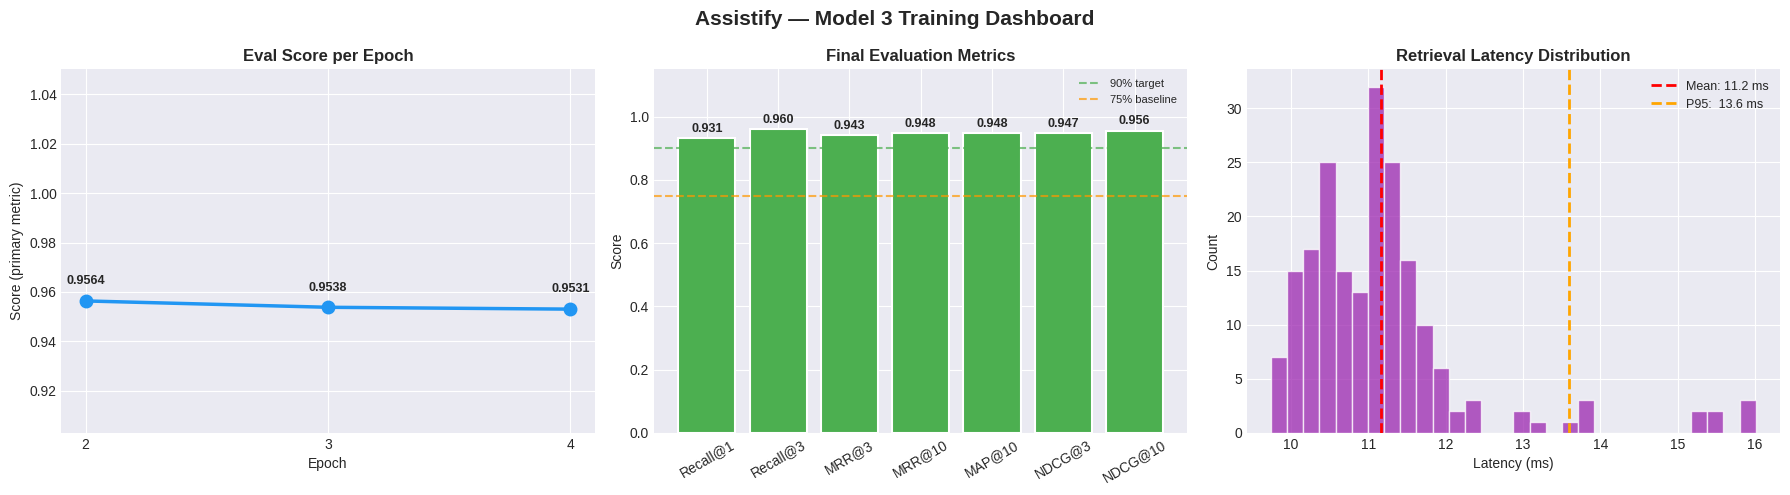

Saved: /kaggle/working/charts/training_dashboard.png


In [34]:
plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Assistify — Model 3 Training Dashboard', fontsize=15, fontweight='bold')

# Chart 1: Eval score per epoch
ax1 = axes[0]
epochs_x = [e['epoch'] for e in eval_log] if eval_log else list(range(1, len(loss_values)+1))
scores_y = [e['score'] for e in eval_log] if eval_log else loss_values
if scores_y:
    ax1.plot(epochs_x, scores_y, 'o-', color='#2196F3', linewidth=2.5, markersize=9)
    for x, y in zip(epochs_x, scores_y):
        ax1.annotate(f'{y:.4f}', (x, y), textcoords='offset points',
                     xytext=(0, 12), ha='center', fontsize=9, fontweight='bold')
    ax1.set_ylim(max(0, min(scores_y) - 0.05), 1.05)
ax1.set_title('Eval Score per Epoch', fontweight='bold', fontsize=12)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Score (primary metric)')
ax1.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# Chart 2: Final metrics bar
ax2 = axes[1]
bar_names = ['Recall@1', 'Recall@3', 'MRR@3', 'MRR@10', 'MAP@10', 'NDCG@3', 'NDCG@10']
bar_vals  = [
    metrics['recall_at_1'], metrics['recall_at_3'],
    metrics['mrr_at_3'],    metrics['mrr_at_10'],
    metrics['map_at_10'],   metrics['ndcg_at_3'],  metrics['ndcg_at_10'],
]
bar_colors = ['#4CAF50' if v >= 0.90 else '#FF9800' if v >= 0.75 else '#F44336' for v in bar_vals]
bars = ax2.bar(bar_names, bar_vals, color=bar_colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, bar_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.axhline(0.90, color='#4CAF50', linestyle='--', alpha=0.7, linewidth=1.5, label='90% target')
ax2.axhline(0.75, color='#FF9800', linestyle='--', alpha=0.7, linewidth=1.5, label='75% baseline')
ax2.set_ylim(0, 1.15)
ax2.set_title('Final Evaluation Metrics', fontweight='bold', fontsize=12)
ax2.set_ylabel('Score')
ax2.tick_params(axis='x', rotation=30)
ax2.legend(fontsize=8)

# Chart 3: Latency distribution
ax3 = axes[2]
ax3.hist(latencies, bins=30, color='#9C27B0', alpha=0.75, edgecolor='white')
ax3.axvline(avg_lat, color='red',    linestyle='--', linewidth=2, label=f'Mean: {avg_lat:.1f} ms')
ax3.axvline(p95_lat, color='orange', linestyle='--', linewidth=2, label=f'P95:  {p95_lat:.1f} ms')
ax3.set_title('Retrieval Latency Distribution', fontweight='bold', fontsize=12)
ax3.set_xlabel('Latency (ms)')
ax3.set_ylabel('Count')
ax3.legend(fontsize=9)

plt.tight_layout()
chart_path = f'{CHARTS_DIR}/training_dashboard.png'
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {chart_path}')

## Step 13 — Inference Test (23 Products — EN + AR)
Test the trained model with sample queries in English and Egyptian Arabic.

In [35]:
PRODUCTS_EN = [
    'Digital Blood Pressure Monitor - hypertension heart blood pressure measurement arm',
    'Wrist Blood Pressure Monitor - hypertension wrist portable blood pressure',
    'Heart Rate Monitor - heart rate pulse cardiac monitoring',
    'Digital Stethoscope - heart lung auscultation doctor medical',
    'Blood Glucose Meter - diabetes sugar glucose test strips finger prick',
    'Smart Glucose Monitor - diabetes smart bluetooth glucose continuous monitoring',
    'Insulin Pen - diabetes insulin injection pen dose',
    'Blood Ketone Meter - diabetes ketones keto ketoacidosis test',
    'Nebulizer Machine - asthma COPD respiratory breathing treatment inhaler steam',
    'Pulse Oximeter - oxygen saturation SpO2 breathing asthma COPD finger clip',
    'Peak Flow Meter - asthma lung function breathing airflow peak flow',
    'Portable Oxygen Concentrator - COPD oxygen therapy breathing portable concentrator',
    'Inhaler Spacer - asthma inhaler spacer puffer bronchodilator respiratory',
    'Digital Thermometer - fever temperature body thermometer',
    'Infrared Ear Thermometer - fever temperature ear forehead infrared',
    'Lightweight Wheelchair - mobility wheelchair disabled elderly transport',
    'Foldable Walking Cane - mobility cane walking stick elderly balance support',
    'Rollator Walker - mobility walker rollator elderly walking frame wheels',
    'Orthopedic Knee Support - knee joint pain support brace orthopedic',
    'Digital Hearing Aid - hearing loss deaf ear amplifier hearing aid',
    'Medical Examination Gloves 100pcs - gloves latex nitrile protective examination',
    'First Aid Kit - first aid emergency bandage wound kit',
    'Digital Medical Scale - weight body mass BMI scale digital',
]

PRODUCTS_AR = [
    'جهاز قياس ضغط الدم الرقمي - ضغط الدم ارتفاع الضغط قياس الضغط يد',
    'جهاز قياس ضغط الدم من المعصم - ضغط الدم ارتفاع الضغط معصم محمول',
    'جهاز قياس نبضات القلب - نبضات القلب معدل ضربات القلب مراقبة القلب',
    'سماعة طبية رقمية - سماعة قلب رئة طبيب فحص طبي',
    'جهاز قياس السكر في الدم - سكر السكري مرض السكر قياس الجلوكوز شرائط',
    'جهاز مراقبة السكر الذكي - سكري بلوتوث ذكي مراقبة مستمرة للسكر',
    'قلم الأنسولين - أنسولين إبرة أنسولين جرعة سكري حقن',
    'جهاز قياس الكيتون في الدم - كيتون حماض كيتوني سكري كيتو',
    'جهاز البخار الطبي - ربو بخار استنشاق شعب هوائية حساسية ضيق تنفس nebulizer',
    'جهاز قياس الأكسجين في الدم - أكسجين تشبع الأكسجين SpO2 ربو تنفس إصبع',
    'جهاز قياس ذروة تدفق الهواء - ربو رئة وظيفة الرئة تدفق الهواء peak flow',
    'جهاز تركيز الأكسجين المحمول - أكسجين COPD انسداد رئوي علاج بالأكسجين محمول',
    'سبيسر الاستنشاق للربو - ربو استنشاق حساسية شعب هوائية موسع inhaler spacer',
    'ميزان حرارة رقمي - حرارة سخونة درجة حرارة الجسم ترمومتر',
    'ميزان حرارة أذن بالأشعة تحت الحمراء - حرارة أذن جبهة أشعة تحت حمراء ترمومتر',
    'كرسي متحرك خفيف الوزن - كرسي متحرك إعاقة كبار السن نقل تنقل',
    'عصا المشي القابلة للطي - عصا مشي توازن كبار السن دعم مشي',
    'مشاية طبية بعجلات - مشاية عجلات توازن مشي مساعدة حركة كبار السن',
    'دعامة الركبة الطبية - ركبة مفصل ألم دعامة جبيرة طبية',
    'سماعة أذن رقمية - ضعف سمع أذن مكبر صوت سمعة طرش',
    'قفازات طبية للفحص 100 قطعة - قفازات لاتكس نتريل واقية فحص طبي',
    'حقيبة الإسعافات الأولية - إسعافات أولية طوارئ ضمادة جرح حقيبة',
    'ميزان طبي رقمي - وزن كتلة جسم BMI ميزان رقمي',
]

NAMES_EN = [
    'Digital Blood Pressure Monitor', 'Wrist Blood Pressure Monitor',
    'Heart Rate Monitor', 'Digital Stethoscope',
    'Blood Glucose Meter', 'Smart Glucose Monitor', 'Insulin Pen', 'Blood Ketone Meter',
    'Nebulizer Machine', 'Pulse Oximeter', 'Peak Flow Meter',
    'Portable Oxygen Concentrator', 'Inhaler Spacer',
    'Digital Thermometer', 'Infrared Ear Thermometer',
    'Lightweight Wheelchair', 'Foldable Walking Cane', 'Rollator Walker', 'Orthopedic Knee Support',
    'Digital Hearing Aid',
    'Medical Examination Gloves 100pcs', 'First Aid Kit', 'Digital Medical Scale',
]
NAMES_AR = [
    'جهاز قياس ضغط الدم الرقمي', 'جهاز قياس ضغط الدم من المعصم',
    'جهاز قياس نبضات القلب', 'سماعة طبية رقمية',
    'جهاز قياس السكر في الدم', 'جهاز مراقبة السكر الذكي', 'قلم الأنسولين', 'جهاز قياس الكيتون في الدم',
    'جهاز البخار الطبي', 'جهاز قياس الأكسجين في الدم', 'جهاز قياس ذروة تدفق الهواء',
    'جهاز تركيز الأكسجين المحمول', 'سبيسر الاستنشاق للربو',
    'ميزان حرارة رقمي', 'ميزان حرارة أذن بالأشعة تحت الحمراء',
    'كرسي متحرك خفيف الوزن', 'عصا المشي القابلة للطي', 'مشاية طبية بعجلات', 'دعامة الركبة الطبية',
    'سماعة أذن رقمية',
    'قفازات طبية للفحص 100 قطعة', 'حقيبة الإسعافات الأولية', 'ميزان طبي رقمي',
]

def recommend(query, top_k=3, lang='en'):
    pool     = PRODUCTS_EN if lang == 'en' else PRODUCTS_AR
    names    = NAMES_EN    if lang == 'en' else NAMES_AR
    pool_emb = best_model.encode(pool, convert_to_tensor=True)
    q_emb    = best_model.encode(query, convert_to_tensor=True)
    scores   = util.cos_sim(q_emb, pool_emb)[0]
    top      = scores.topk(top_k)
    print(f'Query: {query}')
    for score, idx in zip(top.values, top.indices):
        print(f'  {score:.3f}  {names[idx]}')
    print()

print('=== English ===')
recommend('I have hypertension and need to monitor my blood pressure', lang='en')
recommend('My father has asthma, what do you recommend?', lang='en')
recommend('I need a wheelchair for my elderly mother', lang='en')
recommend('My glucose keeps spiking, need a device to track it', lang='en')

print('=== Arabic ===')
recommend('عندي مرض السكري وعايز جهاز مراقبة', lang='ar')
recommend('بدور على جهاز للربو', lang='ar')
recommend('عايز جهاز لقياس السكر بالبلوتوث', lang='ar')
recommend('أبويا عنده صعوبة في المشي، ايه اللي تنصحني بيه؟', lang='ar')

=== English ===
Query: I have hypertension and need to monitor my blood pressure
  0.776  Digital Blood Pressure Monitor
  0.727  Wrist Blood Pressure Monitor
  0.714  Heart Rate Monitor

Query: My father has asthma, what do you recommend?
  0.619  Peak Flow Meter
  0.605  Inhaler Spacer
  0.596  Nebulizer Machine

Query: I need a wheelchair for my elderly mother
  0.812  Lightweight Wheelchair
  0.536  Rollator Walker
  0.505  Foldable Walking Cane

Query: My glucose keeps spiking, need a device to track it
  0.612  Blood Glucose Meter
  0.571  Smart Glucose Monitor
  0.469  Blood Ketone Meter

=== Arabic ===
Query: عندي مرض السكري وعايز جهاز مراقبة
  0.671  جهاز مراقبة السكر الذكي
  0.567  جهاز قياس الكيتون في الدم
  0.519  قلم الأنسولين

Query: بدور على جهاز للربو
  0.599  قلم الأنسولين
  0.571  قفازات طبية للفحص 100 قطعة
  0.544  سماعة طبية رقمية

Query: عايز جهاز لقياس السكر بالبلوتوث
  0.817  جهاز قياس السكر في الدم
  0.746  جهاز مراقبة السكر الذكي
  0.596  قلم الأنسولين

Query: 

## Step 14 — Upload to HuggingFace Hub
Push the best model + eval results + training chart + dataset to `s-rahma/assistify-recommendation-model`.

In [37]:
from kaggle_secrets import UserSecretsClient
from huggingface_hub import HfApi, login

secrets  = UserSecretsClient()
HF_TOKEN = secrets.get_secret('HF_TOKEN')
login(token=HF_TOKEN)

api = HfApi(token=HF_TOKEN)
api.create_repo(repo_id=HF_REPO, repo_type='model', exist_ok=True)

best_model.push_to_hub(
    repo_id        = HF_REPO,
    token          = HF_TOKEN,
    exist_ok       = True,
    commit_message = 'Fine-tuned paraphrase-multilingual-MiniLM-L12-v2 — Assistify 23-product recommendation',
)

for local, remote in [
    (f'{OUTPUT_DIR}/eval_results.json', 'eval_results.json'),
    (chart_path,                         'training_dashboard.png'),
    (DATA_PATH,                           'recommendation_training_dataset.jsonl'),
]:
    api.upload_file(
        path_or_fileobj = local,
        path_in_repo    = remote,
        repo_id         = HF_REPO,
        repo_type       = 'model',
    )
    print(f'Uploaded: {remote}')

print(f'\nDone! https://huggingface.co/{HF_REPO}')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Uploaded: eval_results.json


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Uploaded: training_dashboard.png


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Uploaded: recommendation_training_dataset.jsonl

Done! https://huggingface.co/s-rahma/assistify-recommendation-model
